En este trabajo se estudia el problema de contorno no lineal, dado por:
		$$T''(x)-\sigma^2 (T(x)) T(x)=-f(x) \ , \ 0<x<L$$
		$$T'(0)=\beta T(0)-\gamma $$
		$$T(L)=\delta $$
		$$f(x)=F_0 e^{-\mu x}$$
donde $\sigma^2(T)$ es una función tipo sigmoide:
$$	\sigma^2(T) = \sigma_{\min}^2 + \frac{\sigma_{\max}^2 - \sigma_{\min}^2}{1 + e^{-k(T - T_c)}}
$$
donde $\sigma_{\min}^2$ y $\sigma_{\max}^2$ representan los valores asintóticos del coeficiente a bajas y altas temperaturas, respectivamente, $T_c$ representa la temperatura crítica de transición, y $k$ define la sensibilidad o pendiente del cambio de fase.
Se propone el esquema de diferencias finitas de segundo orden con nodo fantasma. El problema se resuelve mediante la librería <b>NonLinearSolve.jl</b>, que permi.

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


 SOLVER COMPLETO: Success


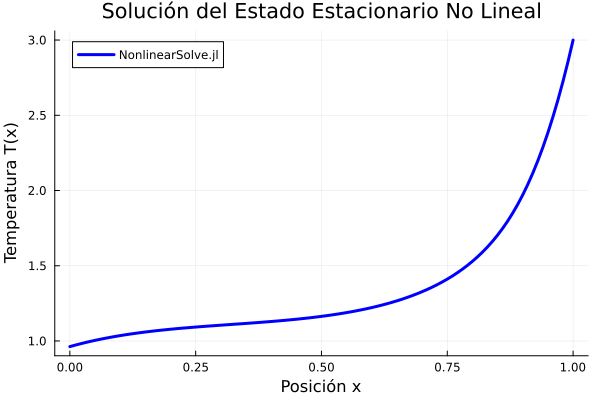

In [3]:
# ==========================================
# PREPARACIÓN DEL ENTORNO
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

using LinearAlgebra
using Plots
using NonlinearSolve  # <-- La librería específica

function simular_estacionario_with_solver()
    L, β, γ, δ = 1.0, 1.5, 0.5, 3.0
    F0, μ = 10.0, 1.0
    
    σ2_min, σ2_max, Tc, k_sig = 2.0^2, 6.0^2, 1.6, 5.0
    calcular_σ2(T) = σ2_min + (σ2_max - σ2_min) / (1.0 + exp(-k_sig * (T - Tc)))

    N = 100
    dx = L / N
    x_nodos = collect(0:dx:L)
    f(x) = F0 * exp(-μ * x)

    # =================================================================
    # DEFINE EL SISTEMA NO LINEAL: F(T) = 0
    # =================================================================
    # En NonlinearSolve, definimos una función que calcula el "residuo" 
    # (cuánto se desvía nuestro sistema de cero para una T dada).
    function f_residuo!(F, T, p)
        σ2_local = calcular_σ2.(T)

        # Nodo i = 0 (Frontera Robin con Nodo Fantasma)
        # T[1] representa T_0
        F[1] = -(1/dx^2 + β/dx + σ2_local[1]/2)*T[1] + (1/dx^2)*T[2] - (-f(0)/2 - γ/dx)

        # Nodos internos i = 1 a N-2 (en Julia, índices 2 a N-1)
        for i in 2:N-1
            xi = (i-1) * dx
            F[i] = (1/dx^2)*T[i-1] - (2/dx^2 + σ2_local[i])*T[i] + (1/dx^2)*T[i+1] - (-f(xi))
        end

        # Nodo i = N-1 (en Julia, índice N, conecta con Dirichlet T_N = δ)
        F[N] = (1/dx^2)*T[N-1] - (2/dx^2 + σ2_local[N])*T[N] - (-f((N-1)*dx) - δ/dx^2)
    end

    # Condición inicial para el solver (un vector de ceros o aproximación)
    T_inicial = fill(1.5, N)

    # Creamos el problema no lineal
    prob = NonlinearProblem(f_residuo!, T_inicial)

    # Resolvemos usando el algoritmo robusto por defecto (Newton con líneas de búsqueda)
    # y especificamos una tolerancia estricta
    sol = solve(prob, abstol=1e-6)

    println("="^50)
    println(" SOLVER COMPLETO: ", sol.retcode)
    println("="^50)

    # Acoplamos el nodo Dirichlet final
    T_final_solver = [sol.u; δ]

    # Graficar
    plot(x_nodos, T_final_solver, lw=3, color=:blue, label="NonlinearSolve.jl", grid=true)
    title!("Solución del Estado Estacionario No Lineal")
    xlabel!("Posición x")
    ylabel!("Temperatura T(x)")
end

simular_estacionario_with_solver()